# Format the DRP CHEOPS data for lisa <a id="top"></a>

- [Single visit analysis](#single)
<!-- - [Batch process](#batch) -->

In [82]:
import os
from collections import OrderedDict
import numpy as np
import pprint

from loguru import logger

import importlib
import tools_format4lisa as tools
importlib.reload(tools)


<module 'tools_format4lisa' from '/Users/olivier/Projects/CHEOPS/Axis3/targets_studied/WASP-43/formatdata4lisa/tools_format4lisa.py'>

In [83]:
# Chose the matplotlib render to get interactive plot
%matplotlib ipympl

In [84]:
# Setup the logger
os.makedirs("logs", exist_ok=True)
logger.add("logs/loguru.log", rotation="1 day")

4

## Target definition and input and output folder definition

In [ ]:
target_name = "WASP-43"
data_folder = f'<Parent Directory where you put the CHEOPS visits folders for the target>'
logger.info(f"Target {target_name}")
logger.info(f"Input folder {data_folder}")

folder_formatedfiles = "lisa_formated_data"
folder_diagnostics = "diagnostics"
os.makedirs(folder_formatedfiles, exist_ok=True)
os.makedirs(folder_diagnostics, exist_ok=True)
logger.info(f"Output folder for lisa formated files: {folder_formatedfiles}")
logger.info(f"Output folder for the diagnostics: {folder_diagnostics}")

2026-05-05 10:25:27.952 | INFO     | __main__:<module>:3 - Target WASP-43
2026-05-05 10:25:27.954 | INFO     | __main__:<module>:4 - Input folder /Volumes/CAUP1bis/Data/lightcurve/CHEOPS/WASP-43/DRP/*
2026-05-05 10:25:27.955 | INFO     | __main__:<module>:10 - Output folder for lisa formated files: lisa_formated_data
2026-05-05 10:25:27.956 | INFO     | __main__:<module>:11 - Output folder for the diagnostics: diagnostics


## Looking for Visits in input folder

In [ ]:
visit_folders = tools.look_for_available_visits(data_folder=data_folder)

2026-05-05 10:25:28.714 | INFO     | tools_format4lisa:look_for_available_visits:92 - Found 1 programs
2026-05-05 10:25:28.715 | INFO     | tools_format4lisa:look_for_available_visits:94 - 140063: Found 1 visits:
2026-05-05 10:25:28.716 | INFO     | tools_format4lisa:look_for_available_visits:96 - In program 140063, visit 2810, Found 1 versions found:
{300: '/Volumes/CAUP1bis/Data/lightcurve/CHEOPS/WASP-43/DRP/PR140063_TG002810_V0300'}


## Single visit analysis <a id = "single"></a>

[Top of the file](#top)

### Specify the visit to analyze and chose the aperture

In [ ]:
id_visit = 2810
program = 140063
version = 300

# Looking at the DRP reports Table 19. columns DIFF MAD and CDPP10m and CDPP3h
aperture = "R18"

# Dataset number that you want to give to this visit
dst_nb = 0

### Define the parameters for the outliers detection: EVENT Flags, Background, Flux...

In [90]:
detect_outliers_params = OrderedDict()
detect_outliers_params["TEMP"] = {"col": "TEMP", 'method': ">=", "threshold": 1}
detect_outliers_params["EARTH"] = {"col": "EARTH", 'method': ">=", "threshold": 1}
detect_outliers_params["MOON"] = {"col": "MOON", 'method': ">=", "threshold": 1}
detect_outliers_params["SUN"] = {"col": "SUN", 'method': ">=", "threshold": 1}
detect_outliers_params["COSMICS"] = {"col": "COSMICS", 'method': ">=", "threshold": 2}
detect_outliers_params["POINTING_JITTER"] = {"col": "POINTING_JITTER", 'method': ">=", "threshold": 1}
detect_outliers_params["x"] = {"col": "CENTROID_X", 'method': "KDE", "prob_threshold": 10e-3 / 2, "kernel": "epanechnikov", "bandwidth": 50, "npt_samp": 10000}
detect_outliers_params["y"] = {"col": "CENTROID_Y", 'method': "KDE", "prob_threshold": 10e-3 / 2, "kernel": "epanechnikov", "bandwidth": 50, "npt_samp": 10000}
detect_outliers_params["bkg"] = {"col": "BACKGROUND", "method": "KDE", "prob_threshold": 20e-3, "kernel": "epanechnikov", "bandwidth": 50, "npt_samp": 10000}
detect_outliers_params["smear"] = {"col": "SMEARING_LC", "method": "KDE", "prob_threshold": 1e-3, "kernel": "epanechnikov", "bandwidth": 50, "npt_samp": 10000}
detect_outliers_params["contam"] = {"col": "CONTA_LC", "method": ">=", "threshold": 5e-3}
detect_outliers_params["TF2"] = {"col": "thermFront_2", "method":"sigma clip flatten", "lvl": 3, 'flatten_kwargs': {'method': 'cofiam', 'window_length': 98 / 7 / 60 / 24, 'break_tolerance': 98 / 5 / 60 / 24}}
detect_outliers_params["flux_err"] = {"col": "FLUXERR", "method": "KDE", "prob_threshold": 20e-3, "kernel": "epanechnikov", "bandwidth": 50, "npt_samp": 10000}
detect_outliers_params["flux"] = {"col": "FLUX", "method": "sigma flatten and sigma flatten", 'pre mask': [ "TEMP", "EARTH", "MOON", "SUN", "COSMICS", "bkg"], "lvl_1": 4, "lvl_2": 3.5, 'flatten_kwargs_1': {'method': 'cofiam', 'window_length': 98 / 0.5 / 60 / 24, 'break_tolerance': 98 / 1 / 60 / 24}, 'flatten_kwargs_2': {'method': 'cofiam', 'window_length': 98 / 2 / 60 / 24, 'break_tolerance': 98 / 5 / 60 / 24}}

### Define the quantities to save into lisa formatted files

In [ ]:
quantities = [
    {"output_name": "flux",
     "table_name": "FLUX",
     "table_error_name": "FLUXERR",
     "context": lambda values: {"median_flux": np.median(values)},
     "transform_with_context": lambda values, ctx: values / ctx["median_flux"],
     "transform_error_with_context": lambda errors, ctx: errors / ctx["median_flux"],
    },
    {"table_name": "BACKGROUND", "output_name": "BKG"},
    {"table_name": "CONTA_LC", "output_name": "CONTA"},
    {"table_name": "SMEARING_LC", "output_name": "SMEAR"},
    {"table_name": "CENTROID_X", "output_name": "CX"},
    {"table_name": "CENTROID_Y", "output_name": "CY"},
    {"table_name": "DARK", "output_name": "DARK"},
    {"table_name": "thermFront_2", "output_name": "TF2"},
    {"table_name": "ROLL_ANGLE", "output_name": "ROLL"},
]

### Process the visit: Do the outliers masking and save the unmasked files

In [96]:
overwrite = True
show_plots = True

2026-05-05 10:26:32.688 | DEBUG    | tools_format4lisa:get_LC_file:142 - Found file for aperture R18 and version 300: Filekey=CH_PR140063_TG002810, path=/Volumes/CAUP1bis/Data/lightcurve/CHEOPS/WASP-43/DRP/PR140063_TG002810_V0300/CH_PR140063_TG002810_TU2026-03-29T05-29-13_SCI_COR_Lightcurve-R18_V0300.fits
2026-05-05 10:26:32.688 | DEBUG    | tools_format4lisa:get_SubArray_file:189 - Found RAW SubArray file for version 300: Filekey=CH_PR140063_TG002810, path=/Volumes/CAUP1bis/Data/lightcurve/CHEOPS/WASP-43/DRP/PR140063_TG002810_V0300/CH_PR140063_TG002810_TU2026-03-29T05-29-13_SCI_RAW_SubArray_V0300.fits
2026-05-05 10:26:32.689 | INFO     | tools_format4lisa:process_visit:1288 - Processing CH_PR140063_TG002810, data version 300, aperture R18, dataset 0.
2026-05-05 10:26:32.690 | INFO     | tools_format4lisa:process_visit:1291 - Lightcurve file: /Volumes/CAUP1bis/Data/lightcurve/CHEOPS/WASP-43/DRP/PR140063_TG002810_V0300/CH_PR140063_TG002810_TU2026-03-29T05-29-13_SCI_COR_Lightcurve-R18_V0

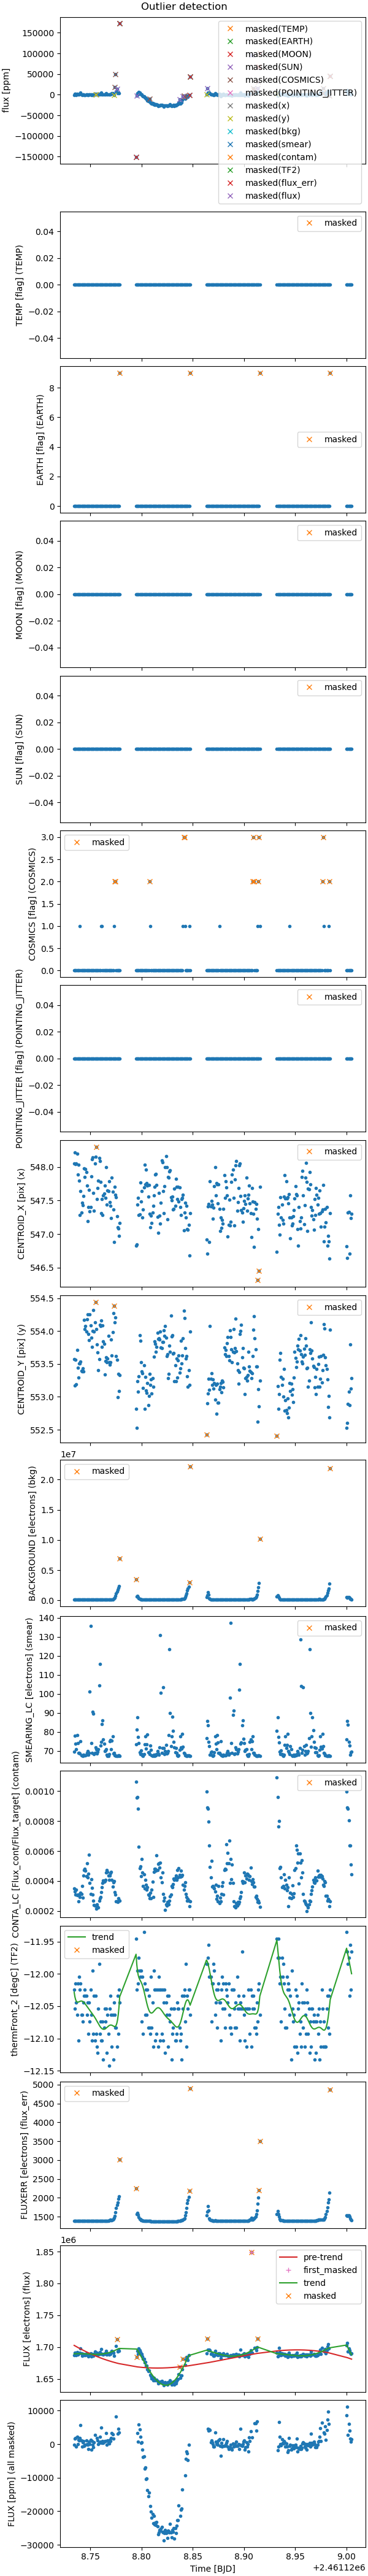

2026-05-05 10:26:33.498 | INFO     | tools_format4lisa:_write_lisa_file:1128 - Created file lisa_formated_data/LC_WASP-43_CHEOPS_0.txt.
2026-05-05 10:26:33.503 | INFO     | tools_format4lisa:_write_lisa_file:1128 - Created file lisa_formated_data/IND-BKG_WASP-43_CHEOPS_0.txt.
2026-05-05 10:26:33.514 | INFO     | tools_format4lisa:_write_lisa_file:1128 - Created file lisa_formated_data/IND-CONTA_WASP-43_CHEOPS_0.txt.
2026-05-05 10:26:33.517 | INFO     | tools_format4lisa:_write_lisa_file:1128 - Created file lisa_formated_data/IND-SMEAR_WASP-43_CHEOPS_0.txt.
2026-05-05 10:26:33.577 | INFO     | tools_format4lisa:_write_lisa_file:1128 - Created file lisa_formated_data/IND-CX_WASP-43_CHEOPS_0.txt.
2026-05-05 10:26:33.582 | INFO     | tools_format4lisa:_write_lisa_file:1128 - Created file lisa_formated_data/IND-CY_WASP-43_CHEOPS_0.txt.
2026-05-05 10:26:33.607 | INFO     | tools_format4lisa:_write_lisa_file:1128 - Created file lisa_formated_data/IND-DARK_WASP-43_CHEOPS_0.txt.
2026-05-05 10:2

{'path_LC_file': '/Volumes/CAUP1bis/Data/lightcurve/CHEOPS/WASP-43/DRP/PR140063_TG002810_V0300/CH_PR140063_TG002810_TU2026-03-29T05-29-13_SCI_COR_Lightcurve-R18_V0300.fits',
 'path_RAW_SubArray_file': '/Volumes/CAUP1bis/Data/lightcurve/CHEOPS/WASP-43/DRP/PR140063_TG002810_V0300/CH_PR140063_TG002810_TU2026-03-29T05-29-13_SCI_RAW_SubArray_V0300.fits',
 'filekey': 'CH_PR140063_TG002810',
 'version': 300,
 'mask': <Column name='BJD_TIME' dtype='bool' unit='day' length=302>
 False
 False
 False
 False
 False
 False
 False
 False
 False
 False
 False
 False
   ...
 False
  True
  True
 False
 False
 False
 False
 False
 False
 False
 False,
 'summary_file': 'diagnostics/summary_WASP-43_CHEOPS_0.txt',
 'folder_outputs': 'lisa_formated_data',
 'folder_diagnostics': 'diagnostics'}

In [ ]:
tools.process_visit(visit_folder_path=visit_folders[program][id_visit][version],
    aperture=aperture,
    dst_nb=dst_nb,
    target_name=target_name,
    quantities=quantities,
    time=None,
    folder_outputs=folder_formatedfiles,
    folder_diagnostics=folder_diagnostics,
    detect_outliers_params=detect_outliers_params,
    masks_to_combine=None,
    show_plots=show_plots,
    overwrite=overwrite,
)